# Micheal 500-Hz time-cross decoding × TW correlation

本 notebook 使用 `michael_alpha_time_cross_fir_timepoint_500hz_toi3p8_4p3_trialwise_only` 中的单-trial time-cross decoding。

**数据范围必须如实区分：** TW 分析窗口为 **1.8–4.3 s**；新 decoding 文件实际仅包含 **3.800–4.298 s**（250 点，每 2 ms 一个点），因此 training/test 轴不可能扩展到 1.8 s。下面分别进行包含 train=test diagonal 和排除 diagonal 的探索性三维相关。

In [11]:
from pathlib import Path
import gc
import importlib
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

PROJECT_DIR = Path('/home/dilay/project2/tw')
MODULE_DIR = PROJECT_DIR / 'travelling_waves/tw/fft/micheal/corr/cross_corr'
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
import michael_tw_cross_correlation as cross_corr
cross_corr = importlib.reload(cross_corr)

TW_DIR = PROJECT_DIR / 'results/micheal_fft'
DECODING_DIR = PROJECT_DIR / 'results/michael_alpha_time_cross_fir_timepoint_100hz_toi1p8_3p8_trialwise_only'
OUTPUT_DIR = DECODING_DIR / 'tw_cross_correlation_tw1p8-4p3_dec3p8-4p3'
FIGURE_DIR = OUTPUT_DIR / 'fig'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TW_LIMITS = (1.8, 3.8)
REQUESTED_DECODING_LIMITS = (1.8, 3.8)
FMIN, FMAX = 8, 12.0
TW_STRIDE = DECODING_STRIDE = 1
N_PERMUTATIONS = 1000
CLUSTER_ALPHA = CLUSTER_P = 0.05
SEED = 42
MEASURES = ('fw', 'bw')
COMPONENTS = ('difference', 'contra', 'ipsi', 'midline', 'all_lines')
CONDITIONS = ('early', 'late', 'early_minus_late')
ANALYSES = tuple(
    (measure, component, condition)
    for measure in MEASURES
    for component in COMPONENTS
    for condition in CONDITIONS
)

decoding_files = sorted(DECODING_DIR.glob('subject_*_alpha_time_cross_torch.npz'))
if len(decoding_files) != 19:
    raise FileNotFoundError(f'Expected 19 decoding files, found {len(decoding_files)} in {DECODING_DIR}')
with np.load(decoding_files[0], allow_pickle=True) as first_decoding:
    available_decoding_time = np.asarray(first_decoding['time_dec'], dtype=float)
DECODING_LIMITS = (float(available_decoding_time[0]), float(available_decoding_time[-1]))
if DECODING_LIMITS[0] > REQUESTED_DECODING_LIMITS[0] + 1e-9:
    raise ValueError(f'Decoding starts later than requested: {DECODING_LIMITS}')
if DECODING_LIMITS[1] < REQUESTED_DECODING_LIMITS[1] - 0.0021:
    raise ValueError(f'Decoding ends earlier than expected: {DECODING_LIMITS}')
print(f'Decoding files: {len(decoding_files)}')
print(f'TW requested: {TW_LIMITS[0]:.3f}–{TW_LIMITS[1]:.3f} s')
print(f'Decoding actually available: {DECODING_LIMITS[0]:.3f}–{DECODING_LIMITS[1]:.3f} s; n={available_decoding_time.size}')
print(f'Exploratory combinations per analysis: {len(ANALYSES)}')


Decoding files: 19
TW requested: 1.800–3.800 s
Decoding actually available: 1.800–3.800 s; n=201
Exploratory combinations per analysis: 30


## 共用运行函数

每个组合均计算 matched-trial Pearson correlation、session 内 Fisher-z 后被试平均、组水平 3D cluster sign-flip，并打印显著 cluster 的 TW/training/test 范围。统计完成后立即保存 `3D statistic map + Significant 3D cluster` 双面板 PNG。

In [12]:
def run_exploratory_3d(*, exclude_diagonal, label, seed_offset):
    results = {}
    for analysis_index, (measure, component, condition) in enumerate(ANALYSES):
        mode = 'OFF-DIAGONAL' if exclude_diagonal else 'WITH-DIAGONAL'
        print(f'\n=== EXPLORATORY {mode}: {measure.upper()} / {component} / {condition} ===', flush=True)
        subjects, tw_time, train_time, test_time, subject_z, matched_counts = (
            cross_corr.build_subject_cross_maps(
                TW_DIR, DECODING_DIR, measure=measure, component=component,
                condition=condition, fmin=FMIN, fmax=FMAX,
                tw_limits=TW_LIMITS, train_limits=DECODING_LIMITS,
                test_limits=DECODING_LIMITS, tw_stride=TW_STRIDE,
                decoding_stride=DECODING_STRIDE,
            )
        )
        off_diagonal_cells = None
        if exclude_diagonal:
            separation = np.abs(train_time[:, None] - test_time[None, :])
            tolerance = 0.25 * min(
                np.median(np.diff(train_time)), np.median(np.diff(test_time))
            )
            off_diagonal = separation > tolerance
            subject_z = np.where(
                off_diagonal[None, None, :, :], subject_z, 0.0
            ).astype(np.float32, copy=False)
            off_diagonal_cells = int(off_diagonal.sum())
            print(f'  retained {off_diagonal_cells}/{off_diagonal.size} train×test cells', flush=True)
        mean_z, observed_t, clusters, null_max = cross_corr.cluster_signflip_3d(
            subject_z, permutations=N_PERMUTATIONS, cluster_alpha=CLUSTER_ALPHA,
            cluster_p=CLUSTER_P, seed=SEED + seed_offset + analysis_index,
            return_all=True,
        )
        threshold = student_t.ppf(1 - CLUSTER_ALPHA / 2, len(subjects) - 1)
        significant = [cluster for cluster in clusters if cluster['significant']]
        cluster_p_values = sorted(cluster['p'] for cluster in clusters)
        cross_corr.print_significant_cluster_ranges(
            observed_t, clusters, tw_time, train_time, test_time
        )
        tag = f'{measure}_{component}_{condition}'
        figure_path = FIGURE_DIR / f'{label}_{tag}_3d-statistic-cluster.png'
        figure = cross_corr.plot_3d_statistic_cluster_panels(
            observed_t, clusters, tw_time, train_time, test_time, threshold,
            figure_path, title=(
                f'{measure.upper()} TW ({component}, 1.8–4.3 s) × {condition} '
                f'decoding ({DECODING_LIMITS[0]:.3f}–{DECODING_LIMITS[1]:.3f} s) [{mode}]'
            ),
        )
        result = {
            'shape': observed_t.shape,
            'n_significant': len(significant),
            'minimum_corrected_p': cluster_p_values[0] if cluster_p_values else None,
            'off_diagonal_cells': off_diagonal_cells,
            'figure': figure_path,
        }
        results[(measure, component, condition)] = result
        print(result, flush=True)
        print(f'3-D panel figure saved to: {figure_path}', flush=True)
        plt.close(figure)
        del subject_z, mean_z, observed_t, clusters, null_max, figure
        gc.collect()
    print(f'\n{label} summary ({len(results)} combinations):')
    for key, result in results.items():
        print(key, result)
    return results


## 1. 探索性 with-diagonal 3D correlation（全部 TW components）

探索性检验 FW/BW × `difference`、`contra`、`ipsi`、`midline`、`all_lines` × early、late、early−late 的全部组合。保留 `Training time = Test time` 主对角线。每个组合单独进行完整三维 cluster sign-flip；由于同时考察多个方向、component 和 decoding condition，这些结果应明确作为探索性分析报告。

In [8]:
with_diagonal_results = run_exploratory_3d(
    exclude_diagonal=False,
    label='exploratory_tw1p8-4p3_dec3p8-4p3_with-diagonal',
    seed_offset=0,
)



=== EXPLORATORY WITH-DIAGONAL: FW / difference / early ===


subject 01: matched s1=769, s2=770; map=(41, 201, 201)
subject 02: matched s1=826, s2=823; map=(41, 201, 201)
subject 03: matched s1=657, s2=697; map=(41, 201, 201)
subject 04: matched s1=800, s2=789; map=(41, 201, 201)
subject 05: matched s1=787, s2=790; map=(41, 201, 201)
subject 06: matched s1=771, s2=757; map=(41, 201, 201)
subject 07: matched s1=769, s2=771; map=(41, 201, 201)
subject 08: matched s1=775, s2=733; map=(41, 201, 201)
subject 09: matched s1=749, s2=730; map=(41, 201, 201)
subject 10: matched s1=829, s2=823; map=(41, 201, 201)
subject 11: matched s1=772, s2=768; map=(41, 201, 201)
subject 12: matched s1=788, s2=805; map=(41, 201, 201)
subject 13: matched s1=826, s2=808; map=(41, 201, 201)
subject 14: matched s1=674, s2=668; map=(41, 201, 201)
subject 15: matched s1=774, s2=778; map=(41, 201, 201)
subject 16: matched s1=822, s2=817; map=(41, 201, 201)
subject 17: matched s1=820, s2=808; map=(41, 201, 201)
subject 18: matched s1=858, s2=847; map=(41, 201, 201)
subject 19

## 2. 探索性 off-diagonal-only 3D correlation（全部 TW components）

探索性检验 FW/BW × `difference`、`contra`、`ipsi`、`midline`、`all_lines` × early、late、early−late 的全部组合。在三维 cluster sign-flip 前排除 `Training time = Test time` 主对角线；对角线固定为 0，不能形成显著 voxel，也不能连接对角线两侧的 cluster。由于同时考察多个方向、component 和 decoding condition，这些结果应明确作为探索性分析报告。

In [9]:
off_diagonal_results = run_exploratory_3d(
    exclude_diagonal=True,
    label='exploratory_tw1p8-4p3_dec3p8-4p3_off-diagonal',
    seed_offset=10000,
)



=== EXPLORATORY OFF-DIAGONAL: FW / difference / early ===
subject 01: matched s1=769, s2=770; map=(41, 201, 201)
subject 02: matched s1=826, s2=823; map=(41, 201, 201)
subject 03: matched s1=657, s2=697; map=(41, 201, 201)
subject 04: matched s1=800, s2=789; map=(41, 201, 201)
subject 05: matched s1=787, s2=790; map=(41, 201, 201)
subject 06: matched s1=771, s2=757; map=(41, 201, 201)
subject 07: matched s1=769, s2=771; map=(41, 201, 201)
subject 08: matched s1=775, s2=733; map=(41, 201, 201)
subject 09: matched s1=749, s2=730; map=(41, 201, 201)
subject 10: matched s1=829, s2=823; map=(41, 201, 201)
subject 11: matched s1=772, s2=768; map=(41, 201, 201)
subject 12: matched s1=788, s2=805; map=(41, 201, 201)
subject 13: matched s1=826, s2=808; map=(41, 201, 201)
subject 14: matched s1=674, s2=668; map=(41, 201, 201)
subject 15: matched s1=774, s2=778; map=(41, 201, 201)
subject 16: matched s1=822, s2=817; map=(41, 201, 201)
subject 17: matched s1=820, s2=808; map=(41, 201, 201)
subjec

## 3. FW/BW difference 随时间变化（TW 1.8–4.3 s，可单独运行）

使用与相关分析完全相同的 alpha TW 和 `difference = contra − ipsi` 定义。细线为每位被试，粗线和阴影为组均值 ± SEM。

subject 01: valid trials=1539
subject 02: valid trials=1649
subject 03: valid trials=1354
subject 04: valid trials=1589
subject 05: valid trials=1577
subject 06: valid trials=1528
subject 07: valid trials=1540
subject 08: valid trials=1508
subject 09: valid trials=1479
subject 10: valid trials=1652
subject 11: valid trials=1540
subject 12: valid trials=1593
subject 13: valid trials=1634
subject 14: valid trials=1342
subject 15: valid trials=1552
subject 16: valid trials=1639
subject 17: valid trials=1628
subject 18: valid trials=1705
subject 19: valid trials=1523
Saved: /home/dilay/project2/tw/results/michael_alpha_time_cross_fir_timepoint_500hz_toi3p8_4p3_trialwise_only/tw_cross_correlation_tw1p8-4p3_dec3p8-4p3/fig/michael_fw_bw_difference_timecourses_tw1p8-4p3.png


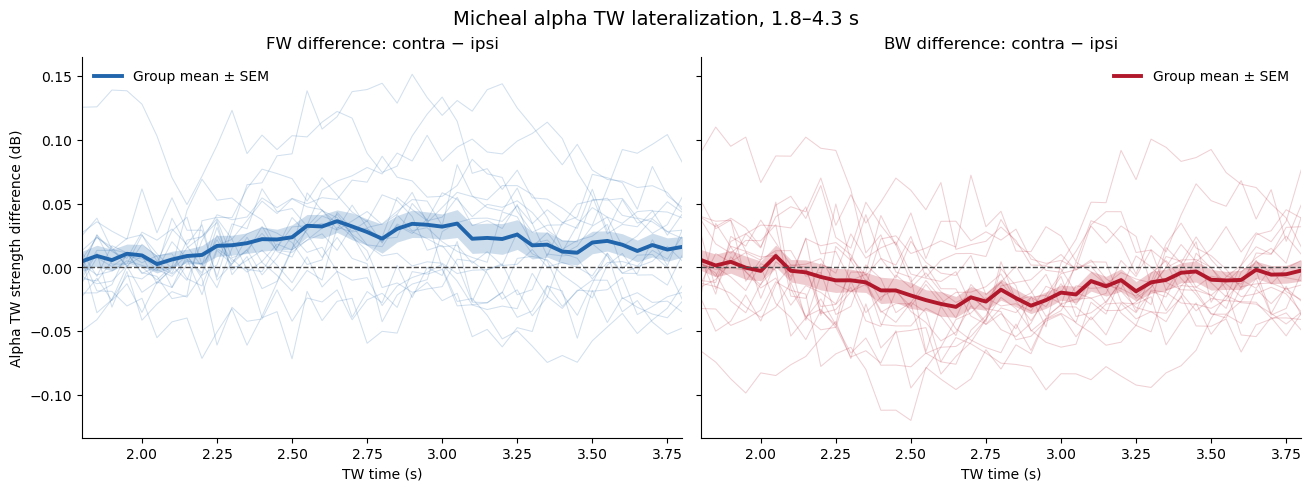

In [10]:
# Standalone FW/BW contra-minus-ipsi TW time courses.
from pathlib import Path
import importlib
import pickle
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path('/home/dilay/project2/tw')
MODULE_DIR = PROJECT_DIR / 'travelling_waves/tw/fft/micheal/corr/cross_corr'
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
import michael_tw_cross_correlation as cross_corr
cross_corr = importlib.reload(cross_corr)
TW_DIR = PROJECT_DIR / 'results/micheal_fft'
DECODING_DIR = PROJECT_DIR / 'results/michael_alpha_time_cross_fir_timepoint_500hz_toi3p8_4p3_trialwise_only'
FIGURE_DIR = DECODING_DIR / 'tw_cross_correlation_tw1p8-4p3_dec3p8-4p3/fig'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
WINDOW = (1.8, 3.8)
FMIN, FMAX = 8.0, 12.0
subject_curves = {'fw': [], 'bw': []}
selected_time = None
for subject in range(1, 20):
    session_curves = {'fw': [], 'bw': []}
    session_weights = []
    for session in (1, 2):
        path = TW_DIR / f'subj{subject:02d}_sess{session}.pkl'
        with path.open('rb') as stream:
            data = pickle.load(stream)
        time = cross_corr._tw_time(data)
        mask = (time >= WINDOW[0] - 1e-9) & (time <= WINDOW[1] + 1e-9)
        if selected_time is None:
            selected_time = time[mask]
        elif not np.allclose(selected_time, time[mask]):
            raise ValueError(f'TW time mismatch in {path.name}')
        frequency = np.asarray(data['ff'], dtype=float)
        frequency_mask = (frequency >= FMIN) & (frequency <= FMAX)
        keep = np.ones(np.asarray(data['cue_loc']).size, dtype=bool)
        if 'is_bad_epoch' in data:
            keep &= ~np.asarray(data['is_bad_epoch'], dtype=bool)
        if 'has_timing_issue' in data:
            keep &= ~np.asarray(data['has_timing_issue'], dtype=bool)
        for measure in ('fw', 'bw'):
            values = cross_corr._tw_measure(data, measure)
            difference = cross_corr._component_array(
                values, np.asarray(data['cue_loc']), 'difference'
            )
            curve = difference[frequency_mask][:, mask, :][:, :, keep].mean(axis=(0, 2))
            session_curves[measure].append(curve)
        session_weights.append(int(keep.sum()))
        del data, values, difference
    for measure in ('fw', 'bw'):
        subject_curves[measure].append(
            np.average(session_curves[measure], axis=0, weights=session_weights)
        )
    print(f'subject {subject:02d}: valid trials={sum(session_weights)}', flush=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True, constrained_layout=True)
styles = {'fw': ('#2166AC', 'FW difference'), 'bw': ('#B2182B', 'BW difference')}
for axis, measure in zip(axes, ('fw', 'bw')):
    curves = np.asarray(subject_curves[measure])
    group_mean = curves.mean(axis=0)
    sem = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])
    color, title = styles[measure]
    for curve in curves:
        axis.plot(selected_time, curve, color=color, lw=.75, alpha=.20)
    axis.fill_between(selected_time, group_mean-sem, group_mean+sem, color=color, alpha=.22, linewidth=0)
    axis.plot(selected_time, group_mean, color=color, lw=2.8, label='Group mean ± SEM')
    axis.axhline(0, color='.3', lw=1, ls='--')
    axis.set(title=f'{title}: contra − ipsi', xlabel='TW time (s)', xlim=WINDOW)
    axis.spines[['top', 'right']].set_visible(False)
    axis.legend(frameon=False)
axes[0].set_ylabel('Alpha TW strength difference (dB)')
fig.suptitle('Micheal alpha TW lateralization, 1.8–4.3 s', fontsize=14)
figure_path = FIGURE_DIR / 'michael_fw_bw_difference_timecourses_tw1p8-4p3.png'
fig.savefig(figure_path, dpi=250, bbox_inches='tight')
print(f'Saved: {figure_path}', flush=True)
plt.show()
